In [130]:
import const
from const import MPRA_data_paths
from const import pos_active_ctrl_color,neg_active_ctrl_color,highlight_color,custom_cmap
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import pysam
import pickle
import regex as re
import collections
import math
const.set_plot_style()
import matplotlib.ticker as ticker
from const import plot_color_pallete
from scipy.optimize import curve_fit
import matplotlib.ticker as mticker
from scipy.stats import gaussian_kde

In [131]:
#define paths
project="L4a4_Indel"
data_path=f"/home/labs/davidgo/Collaboration/MPRA_QC_pipeline/associations/input/{project}"
fasta_path=f"{data_path}/L4a4_Indel.fasta"
working_dir="/home/labs/davidgo/Collaboration/MPRA_QC_pipeline/associations/output/"
output_dir=f"{working_dir}/{project}"
os.makedirs(output_dir,exist_ok=True)

In [132]:
# define flags
final_flag=1
before_promiscuity_flag=1
before_minimum_associations_flag=1
downsampling_flag=1

In [133]:
if final_flag:
    final_df=pd.read_csv(f"{data_path}/final_df.csv",index_col=0)
if before_promiscuity_flag:
    before_prom_df=pd.read_csv(f"{data_path}/before_prom_df.csv",index_col=0)
if before_minimum_associations_flag:
    before_min_assoc_df=pd.read_csv(f"{data_path}/before_min_assoc_df.csv",index_col=0)

In [134]:
def GC_calc(seq):
    c=seq.count("C")+seq.count("c")
    g=seq.count("G")+seq.count("g")
    perc=(c+g)/len(seq)
    return perc

def counts_df_creator(assoc_df,oligos,f_dict):
    grouped_df=assoc_df.groupby('cCRE')
    assoc_count=grouped_df['match_count'].sum()
    bc_count=grouped_df['barcode'].nunique()
    saved_oligos=grouped_df.groups.keys()
    counts_df=pd.DataFrame(data={"barcode_count":bc_count,"association_count":assoc_count})
    lost_oligos=[oligo for oligo in oligos if oligo not in saved_oligos ]
    add_df=pd.DataFrame(data={"barcode_count":0,"association_count":0},index=lost_oligos)
    full_df=pd.concat([counts_df,add_df])
    full_df['gc']=full_df.index.to_series().apply(lambda x: f_dict[x][0])
    full_df['g_stretch']=full_df.index.to_series().apply(lambda x: f_dict[x][1])
    full_df['len']=full_df.index.to_series().apply(lambda x: f_dict[x][2])
    return full_df

def barcode_df_counts_creator(assoc_df):
    grouped_df=assoc_df.groupby('barcode')
    assoc_count=grouped_df['match_count'].sum()
    oligo_count=grouped_df['cCRE'].nunique()
    counts_df=pd.DataFrame(data={"cCRE_count":oligo_count,"association_count":assoc_count})
    return counts_df

In [135]:
fasta_file = pysam.FastxFile(fasta_path)
full_oligo_list=set()
feature_dict={}
for entry in fasta_file:
    if entry.name not in full_oligo_list:
        entry_seq=entry.sequence
        full_oligo_list.add(entry.name)
        gc_val=GC_calc(entry_seq)
        g_stretch = len(max(re.findall("[Gg]" + '+', entry_seq), key = len,default=""))
        seq_len=len(entry_seq)
        feature_dict[entry.name]=[gc_val,g_stretch,seq_len]

In [136]:
if final_flag:
    final_counts_df=counts_df_creator(final_df,full_oligo_list,feature_dict)

### Barcodes per cCRE

In [137]:
if final_flag:
    plt.clf()
    f, ax_ecdf = plt.subplots()
    sns.ecdfplot(final_counts_df['barcode_count'],color=plot_color_pallete['barcode'],ax=ax_ecdf)

    frac_at_zero = (final_counts_df['barcode_count'] <= 0).mean()   # proportion of values ≤ 0
    med = final_counts_df['barcode_count'].median()

    plt.xlabel("Barcode count")
    # Add horizontal line at that y
    plt.axhline(frac_at_zero, color=plot_color_pallete['cCRE'], linestyle="--")
    plt.axvline(med, color=plot_color_pallete['barcode'], linestyle="--")

    plt.text(
        plt.gca().get_xlim()[1]*0.4, frac_at_zero+0.02,  # position text near right side
        f"cCREs with 0 barcodes: {frac_at_zero:.2%}", color=plot_color_pallete['cCRE']
    )

    plt.text(
        med * 2, 0.55,  # position text near right side
        f"Median number of barcodes: {med:.2f}", color=plot_color_pallete['barcode']
    )

    const.save_fig(plt,"Barcodes per cCRE",output_dir)

 ### cCRE-barcode observations

In [138]:
if before_minimum_associations_flag:
    plt.clf()
    f, ax_hist = plt.subplots()
    bin_width = 0.5
    min_val = 0
    max_val = 20

    # Define finer bin edges centered on every 0.5 step
    bin_edges = np.arange(min_val - bin_width/2, max_val + bin_width*1.5, bin_width)
    sns.histplot(data=before_min_assoc_df,x='match_count',ax=ax_hist,color=plot_color_pallete["cCRE-barcode-pair"],
                bins=bin_edges)
    ax_hist.set_xlabel("Number of UMIs")
    ax_hist.set_ylabel("Number of cCRE-barcode pairs",fontsize=const.FONT_SIZE_small)
    ax_hist.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax_hist.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax_hist.set_xticks([1, 20])
    const.save_fig(plt,"cCRE-barcode observations",output_dir)

### Retained cCREs

In [139]:
if final_flag:
    bc_thresholds=np.arange(0,100,1)
    oligo_counts=[]
    for thr in bc_thresholds:
        pass_sum=final_counts_df['barcode_count'].apply(lambda x: x>thr).sum()
        norm_pass_sum=pass_sum/len(full_oligo_list)
        oligo_counts.append(norm_pass_sum)
    bc_thr_df=pd.DataFrame(data={'threshold':bc_thresholds,'perc':oligo_counts})

In [140]:
if final_flag:
    fig, ax = plt.subplots()
    sns.lineplot(data=bc_thr_df,x="threshold",y="perc",color=plot_color_pallete['cCRE'])
    ax.set_ylabel("cCREs retained")
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, _: f"{val * 100:.0f}%"))
    ax.set_xlabel("Minimum barcodes/cCRE threshold")
    ax.set_ylim(0,1)
    const.save_fig(plt,"Retained cCREs",output_dir)

### Barcode promiscuity

In [141]:
if before_promiscuity_flag:
    promiscuity_counts_df=barcode_df_counts_creator(before_prom_df)

In [142]:
if before_promiscuity_flag:
    plt.clf()
    f, ax_hist = plt.subplots()
    bin_width = 0.5
    min_val = promiscuity_counts_df['cCRE_count'].min()
    max_val = 10

    # Define finer bin edges centered on every 0.5 step
    bin_edges = np.arange(min_val - bin_width/2, max_val + bin_width*1.5, bin_width)

    sns.histplot(
        data=promiscuity_counts_df,
        x='cCRE_count',
        ax=ax_hist,
        bins=bin_edges,
        color=plot_color_pallete['barcode'],
        edgecolor=None
    )
    ax_hist.set_xlabel(f'Number of cCREs')
    ax_hist.set_xticks([1, 10])
    ax_hist.set_ylabel("Number of barcodes",fontsize=const.FONT_SIZE_small)
    const.save_fig(plt,"Barcode promiscuity",output_dir)

### PCR bias - GC content

In [143]:
if final_flag:
    gc_bins=pd.cut(final_counts_df['gc'],bins=np.arange(0,1.01,0.05),duplicates="drop")
    final_counts_df['gc_bin']=gc_bins
    bin_sizes=final_counts_df.reset_index().groupby('gc_bin')['index'].nunique()
    bin_df=pd.DataFrame(data={"gc_bin":bin_sizes.index,"bin_size":bin_sizes.values})

    bin_df['gc_bin_center'] = bin_df['gc_bin'].apply(lambda x: (float(x.left)+float(x.right)))
    bin_intervals = bin_df['gc_bin'].cat.categories
    bin_edges = [i.left for i in bin_intervals] + [bin_intervals[-1].right]
    bin_centers = [(i.left + i.right) / 2 for i in bin_intervals]
    bin_widths = [(i.right - i.left)/2 for i in bin_intervals]

    # Get bar heights in the same order
    heights = bin_df.set_index('gc_bin').loc[bin_intervals]['bin_size'].values
    boxplot_df = final_counts_df.copy()
    boxplot_df['gc_bin_center'] = boxplot_df['gc_bin'].apply(lambda x: (float(x.left)+float(x.right))/2)
    boxplot_groups = boxplot_df.groupby('gc_bin_center')['association_count'].apply(list)

In [144]:
if final_flag:
    f, ax_hist = plt.subplots()

    ax_hist.boxplot(x=boxplot_groups.values,positions=boxplot_groups.index,showfliers=False,widths=bin_widths,
                    patch_artist=True,boxprops=dict(facecolor=plot_color_pallete['read']),
        medianprops=dict(color='black', linewidth=1))
    ax_hist.set_xticks(bin_edges)
    ax_hist.set_xticklabels([f"{e:.2f}" for e in bin_edges], fontsize=10)
    ax_hist.set_xlabel("GC content")
    ax_hist.set_ylabel("Number of reads")
    #ax_bar.set_xticks(ax_bar.get_xticks()[::2])
    ax_hist.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax_hist.set_xlim(bin_edges[0], bin_edges[-1])
    ax_hist.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    const.save_fig(plt,"PCR bias - GC content",output_dir)

In [145]:
if final_flag:
    plt.clf()
    gc_summary = boxplot_df.groupby('gc_bin')['association_count'].agg(['count','median']).reset_index()


    fig, ax1 = plt.subplots()
    ax1.bar(boxplot_groups.index, gc_summary['count'],
            color=plot_color_pallete['cCRE'], label='Number of oligos',width=0.025)
    ax1.set_ylabel("Number of oligos")

    ax2 = ax1.twinx()
    ax2.plot(boxplot_groups.index, gc_summary['median'],
             color=plot_color_pallete['read'], marker='o', label='Median reads per oligo')
    ax2.set_ylabel("Median reads per oligo")

    ax1.set_xlabel("GC content")
    #ax_bar.set_xticks(ax_bar.get_xticks()[::2])
    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax1.set_xticks(bin_edges)          # make sure ticks line up

    ax1.set_xticklabels([f"{e:.2f}" for e in bin_edges], fontsize=8)

    ax1.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

    plt.tight_layout()
    const.save_fig(plt,"PCR bias - GC content summary",output_dir)

### PCR bias - G-stretches

In [146]:
if final_flag:
    f, ax_hist = plt.subplots()

    sns.boxplot(data=final_counts_df,x="g_stretch",y="association_count",showfliers=False,color=plot_color_pallete['read'],ax=ax_hist)
    #ax_bar.tick_params(axis='x', labelsize=6,rotation=45)
    ax_hist.set_ylabel("Reads per oligo",fontsize=const.FONT_SIZE_small)
    ax_hist.set_xlabel("G stretch")
    ax_hist.set_xticklabels(np.arange(final_counts_df['g_stretch'].min(),final_counts_df['g_stretch'].max()+1))

    ax_hist.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    const.save_fig(plt,"PCR bias - G-stretches",output_dir)

In [147]:
if final_flag:
    plt.clf()
    gc_summary = final_counts_df.groupby('g_stretch')['association_count'].agg(['count','median']).reset_index()


    fig, ax1 = plt.subplots()
    ax1.bar(gc_summary['g_stretch'], gc_summary['count'],
            color=plot_color_pallete['cCRE'], label='Number of oligos')
    ax1.set_ylabel("Number of oligos")
    ax1.set_xticks([final_counts_df['g_stretch'].min(),final_counts_df['g_stretch'].max()])

    ax2 = ax1.twinx()
    ax2.plot(gc_summary['g_stretch'], gc_summary['median'],
             color=plot_color_pallete['read'], marker='o', label='Median reads per oligo')
    ax2.set_ylabel("Median reads per oligo")

    ax1.set_xlabel("G stretch")
    #ax_bar.set_xticks(ax_bar.get_xticks()[::2])
    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))


    plt.tight_layout()
    const.save_fig(plt,"PCR bias - G-stretches summary",output_dir)

### Downsampling analysis

In [148]:
if downsampling_flag:
    project="L4a4_Indel"
    data_path=f"/home/labs/davidgo/Collaboration/MPRA_QC_pipeline/associations/input/{project}/"
    fasta_path=f"{data_path}/L4a4_Indel.fasta"
    working_dir="/home/labs/davidgo/Collaboration/MPRA_QC_pipeline/associations/output/"
    output_dir=f"{working_dir}/{project}"
    minimum_barcode_sequence_quality = 30
    minimum_number_reads_associating_barcode_to_oligo = 2
    minimum_oligo_mapping_quality = 6
    downsampling_perc_list=np.arange(0.1,1.01,0.1)
    subset="total"

In [149]:
def downsampling_bc_counts(assoc_df,group):
    if group=='total':
        final_df=assoc_df.copy()
    else:
        final_df=assoc_df[assoc_df['oligo'].apply(lambda x: bool(re.findall(group,x)))].copy() # filter by group - take only necessary oligos
    bc_counts = final_df.groupby('oligo')['bc_seq'].size()
    return pd.DataFrame(data={'bc_counts':bc_counts})

# Hill model
def hill_model(x, a, b, n):
    return a * x**n / (b**n + x**n)
def r_squared(y_true, y_pred):
    ss_total = np.sum((y_true - np.mean(y_true))**2)
    ss_residual = np.sum((y_true - y_pred)**2)
    return 1 - (ss_residual / ss_total)

In [150]:
if downsampling_flag:
    fasta_file = pysam.FastxFile(fasta_path)
    full_oligo_list=set()
    gc_dict={}
    for entry in fasta_file:
        if entry.name not in full_oligo_list:
            full_oligo_list.add(entry.name)
    total_oligos=len(full_oligo_list)

In [151]:
if downsampling_flag:
    dfs=[]
    for p in downsampling_perc_list:
        perc=round(p,1)
        print(perc)
        path=fr"{data_path}/downsampling/oligos_to_barcodes_comb_30_{minimum_number_reads_associating_barcode_to_oligo}_{perc}.txt"
        df=pd.read_csv(path)
        curr_df=downsampling_bc_counts(df, subset)
        curr_df['ds']=perc
        dfs.append(curr_df)

    downsampling_df_total=pd.concat(dfs)
    oligo_coverage=downsampling_df_total.groupby('ds')['bc_counts'].size()/total_oligos
    oligo_coverage_df=pd.DataFrame(data={"ds":oligo_coverage.index.to_list(),"oligo_coverage":oligo_coverage.values})
    oligo_coverage_df['ds']=oligo_coverage_df['ds'].apply(lambda x: str(x))

0.1
0.2
0.3
0.4
0.5
0.6
0.7
0.8
0.9
1.0


In [152]:
if downsampling_flag:
    x_arr=oligo_coverage_df['ds'].to_numpy(dtype=float)
    y_arr=oligo_coverage_df['oligo_coverage'].to_numpy(dtype=float)


    params_hill, _ = curve_fit(hill_model, x_arr, y_arr, bounds=(0, np.inf))

    #create datapoints for plotting
    x_fit = np.linspace(0.1, 3, 100)
    y_hill_fit = hill_model(x_fit,*params_hill)
    r2_hill = r_squared(y_arr, hill_model(x_arr, *params_hill))
    mse_hill = np.mean((y_arr -hill_model(x_arr, *params_hill))**2)
    #predict coverage for higher sequencing values
    x_pred=np.array([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1,1.2,1.5,1.75,2,2.5,3])
    y_pred=hill_model(x_pred,*params_hill)
    pred_df=pd.DataFrame(data={"x":x_pred,"predicted coverage_hill":y_pred})
    pred_df.to_csv(fr"{output_dir}/coverage_predictions_hill.csv")


Hill Model R^2: 0.9999
Hill MSE: 0.0000
0.8799076212471132 0.9015910479358802


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


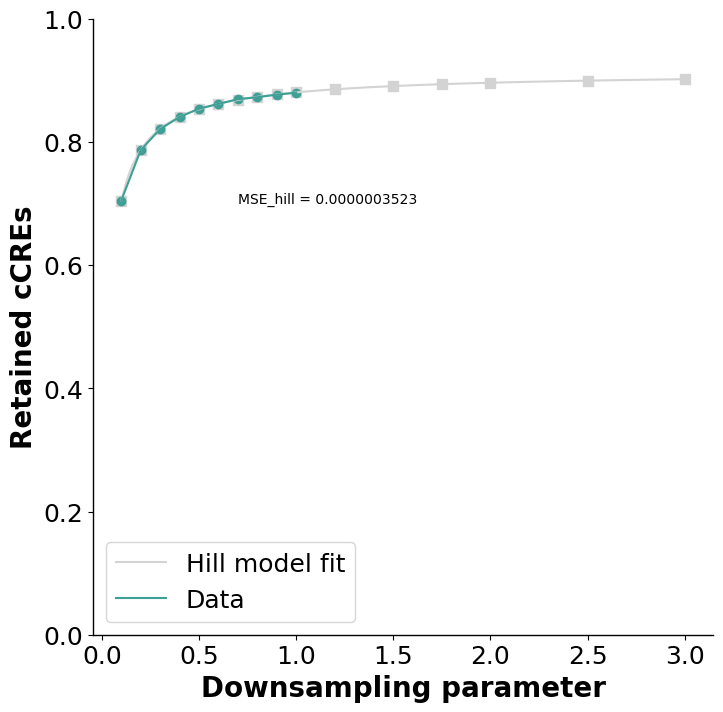

In [153]:
if downsampling_flag:
    plt.clf()
    # Output comparison results
    print(f"Hill Model R^2: {r2_hill:.4f}")
    print(f"Hill MSE: {mse_hill:.4f}")

    plt.clf()
    plt.scatter(x_pred, y_pred, color='lightgray',marker="s",s=60)
    plt.scatter(x_arr, y_arr,color=plot_color_pallete['cCRE'])
    plt.plot(x_fit, y_hill_fit, label='Hill model fit', color='lightgray')
    plt.plot(x_arr, y_arr, label='Data',color=plot_color_pallete['cCRE'])

    plt.legend()
    plt.xlabel('Downsampling parameter')
    plt.ylabel('Retained cCREs')
    plt.text(s=f'MSE_hill = {mse_hill:.10f}',y=0.7,x=0.7)
    print(y_arr[-1],y_hill_fit[-3])
    plt.ylim(0,1)
    const.save_fig(plt,"Downsampling - Retained cCREs",output_dir)

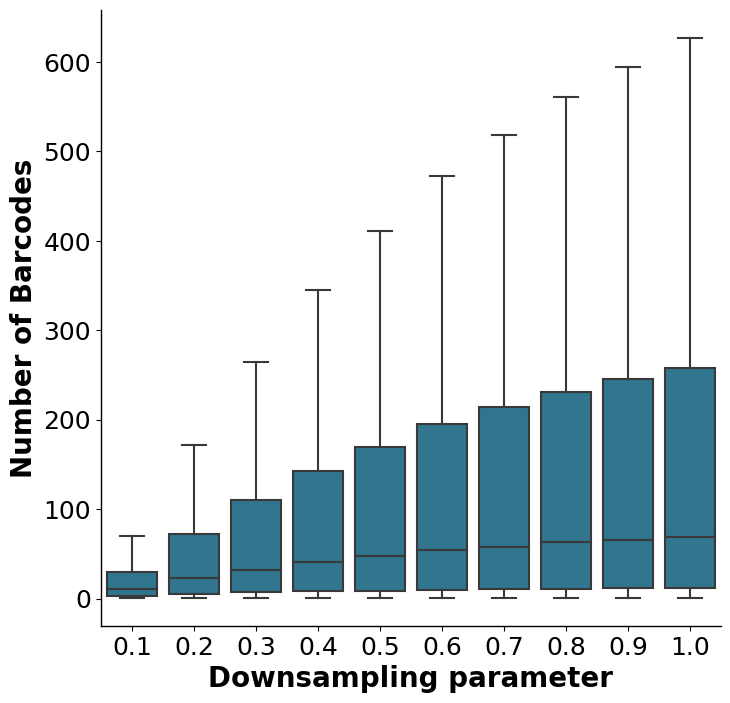

In [154]:
if downsampling_flag:
    f, ax_box= plt.subplots()
    sns.boxplot(data=downsampling_df_total,y='bc_counts',x='ds',showfliers=False,ax=ax_box,color=plot_color_pallete['barcode'])
    ax_box.set_xlabel("Downsampling parameter")
    ax_box.set_ylabel("Number of Barcodes")
    const.save_fig(plt,"Downsampling - Barcodes per cCRE",output_dir)